
===== Personal Fitness Tracker =====
1. Log Activity
2. View Summary Metrics
3. Filter Activity
4. Generate Report
5. Visualize Data
6. Exit


Enter your choice:  1
Enter Activity Type:  Dance
Enter Duration (Minutes):  30
Enter Calories Burned:  20


✅ Activity logged successfully!

===== Personal Fitness Tracker =====
1. Log Activity
2. View Summary Metrics
3. Filter Activity
4. Generate Report
5. Visualize Data
6. Exit


Enter your choice:  1
Enter Activity Type:  running
Enter Duration (Minutes):  30
Enter Calories Burned:  60


✅ Activity logged successfully!

===== Personal Fitness Tracker =====
1. Log Activity
2. View Summary Metrics
3. Filter Activity
4. Generate Report
5. Visualize Data
6. Exit


...

Enter your choice:  3
Enter Activity Type to Filter:  Dance


         Date Activity Type  Duration (Minutes)  Calories Burned
3  2026-02-19         Dance                30.0             20.0

===== Personal Fitness Tracker =====
1. Log Activity
2. View Summary Metrics
3. Filter Activity
4. Generate Report
5. Visualize Data
6. Exit


Enter your choice:  4



📋 Activity Report
         Date Activity Type  Duration (Minutes)  Calories Burned
0  2026-02-19  registration                 5.0              1.0
1  2026-02-19         dance                 5.0             50.0
2  2026-02-19             1                 5.0             20.0
3  2026-02-19         Dance                30.0             20.0
4  2026-02-19       running                30.0             60.0

⏱ Total Time Spent per Activity:
Activity Type
1                5.0
Dance           30.0
dance            5.0
registration     5.0
running         30.0
Name: Duration (Minutes), dtype: float64

===== Personal Fitness Tracker =====
1. Log Activity
2. View Summary Metrics
3. Filter Activity
4. Generate Report
5. Visualize Data
6. Exit


Enter your choice:  5


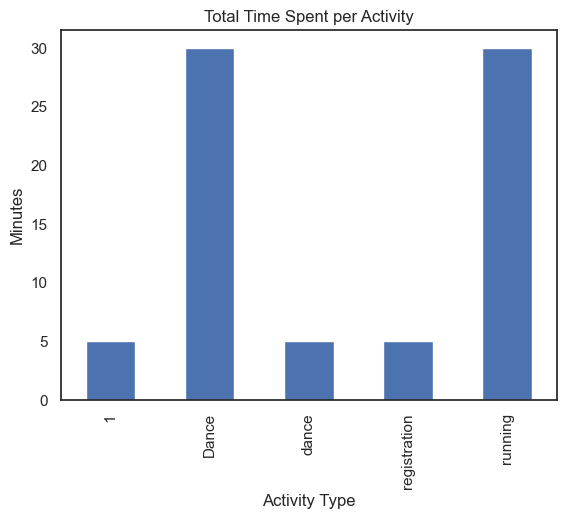

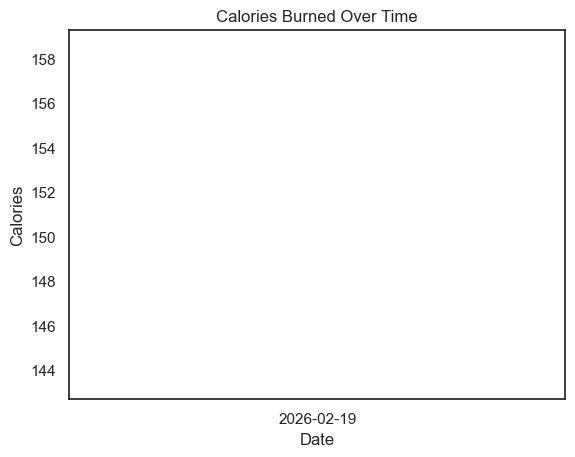

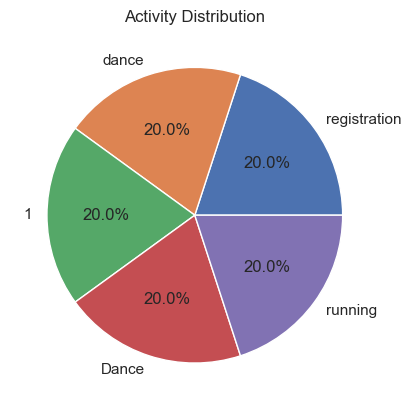

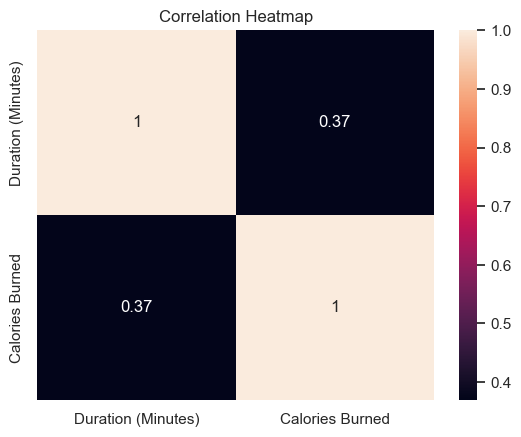


===== Personal Fitness Tracker =====
1. Log Activity
2. View Summary Metrics
3. Filter Activity
4. Generate Report
5. Visualize Data
6. Exit


Enter your choice:  6


Exiting Program...


In [3]:
# ==============================
# Personal Fitness Tracker Dashboard
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


class FitnessTracker:

    def __init__(self, filename="fitness_activities.csv"):
        self.filename = filename

        # If file exists, load it. Otherwise create empty dataframe.
        if os.path.exists(self.filename):
            self.data = pd.read_csv(self.filename)
        else:
            self.data = pd.DataFrame(columns=[
                "Date", "Activity Type", "Duration (Minutes)", "Calories Burned"
            ])
            self.data.to_csv(self.filename, index=False)

    # ==============================
    # 1. Log Activity
    # ==============================
    def log_activity(self, activity_type, duration, calories):
        if duration <= 0 or calories <= 0 :
            print("❌ Duration and Calories must be positive numbers.")
            return

        

        date = pd.Timestamp.today().strftime("%Y-%m-%d")

        new_entry = {
            "Date": date,
            "Activity Type": activity_type,
            "Duration (Minutes)": duration,
            "Calories Burned": calories
        }

        self.data = pd.concat([self.data, pd.DataFrame([new_entry])],
                              ignore_index=True)

        self.data.to_csv(self.filename, index=False)
        print("✅ Activity logged successfully!")

        

    # ==============================
    # 2. Calculate Metrics 
    # ==============================
    def calculate_metrics(self):
        if self.data.empty:
            print("⚠ No data available.")
            return

        durations = self.data["Duration (Minutes)"].values
        calories = self.data["Calories Burned"].values

        total_calories = np.sum(calories)
        avg_duration = np.mean(durations)
        max_calories = np.max(calories)

        print("\n📊 Fitness Summary")
        print("----------------------")
        print(f"Total Calories Burned: {total_calories}")
        print(f"Average Duration: {avg_duration:.2f} minutes")
        print(f"Highest Calories Burned in a session: {max_calories}")
        

    # ==============================
    # 3. Filter Activities
    # ==============================

    
    def filter_activities(self, activity_type):
        filtered = self.data[self.data["Activity Type"] == activity_type]

        if filtered.empty:
            print("⚠ No matching activity found.")
        else:
            print(filtered)

            

    # ==============================
    # 4. Generate Report
    # ==============================

    
    def generate_report(self):
        if self.data.empty:
            print("⚠ No data available for report.")
            return

        print("\n📋 Activity Report")
        print(self.data)

        grouped = self.data.groupby("Activity Type")["Duration (Minutes)"].sum()
        print("\n⏱ Total Time Spent per Activity:")
        print(grouped)


        

    # ==============================
    # 5. Visualizations 
    # ==============================

    
    def visualize(self):

        if self.data.empty:
            print("⚠ No data available for visualization.")
            return

        # Clean style (NO GRID)
        sns.set_style("white")

        # ---- Bar Chart ----
        plt.figure()
        self.data.groupby("Activity Type")["Duration (Minutes)"].sum().plot(kind="bar")
        plt.title("Total Time Spent per Activity")
        plt.ylabel("Minutes")
        plt.grid(False)
        plt.show()

        # ---- Line Graph ----
        plt.figure()
        self.data.groupby("Date")["Calories Burned"].sum().plot(kind="line")
        plt.title("Calories Burned Over Time")
        plt.ylabel("Calories")
        plt.grid(False)
        plt.show()

        # ---- Pie Chart ----
        plt.figure()
        self.data["Activity Type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
        plt.title("Activity Distribution")
        plt.ylabel("")
        plt.grid(False)
        plt.show()

        # ---- Heatmap ----
        plt.figure()
        corr = self.data[["Duration (Minutes)", "Calories Burned"]].corr()
        sns.heatmap(corr, annot=True, linewidths=0)
        plt.title("Correlation Heatmap")
        plt.show()


# ==============================
# Main Menu (Control Structures)
# ==============================

def main():
    tracker = FitnessTracker()

    while True:
        print("\n===== Personal Fitness Tracker =====")
        print("1. Log Activity")
        print("2. View Summary Metrics")
        print("3. Filter Activity")
        print("4. Generate Report")
        print("5. Visualize Data")
        print("6. Exit")

        choice = input("Enter your choice: ")

        if choice == "1":
            activity = input("Enter Activity Type: ")
            duration = float(input("Enter Duration (Minutes): "))
            calories = float(input("Enter Calories Burned: "))
            tracker.log_activity(activity, duration, calories)

        elif choice == "2":
            tracker.calculate_metrics()

        elif choice == "3":
            activity = input("Enter Activity Type to Filter: ")
            tracker.filter_activities(activity)

        elif choice == "4":
            tracker.generate_report()

        elif choice == "5":
            tracker.visualize()

        elif choice == "6":
            print("Exiting Program...")
            break

        else:
            print("❌ Invalid choice. Try again.")


if __name__ == "__main__":
    main()
